# Notebook 03 — Analysis

This notebook explores PM2.5 air quality patterns across 11 monitoring 
stations in Santiago's Región Metropolitana between 2020 and 2025.

## Research questions
- How does PM2.5 vary across months and seasons?
- Which stations record the highest and lowest pollution levels?
- Is there a year-over-year trend in air quality across the period?
- How often do stations exceed Chile's legal daily standard of 50 µg/m³?

## Data source
Clean daily data from `data/interim/air_quality_daily.parquet`, 
produced by `02_clean.ipynb`. Contains 20,162 station-day records 
across 11 stations, 2020–2025.


In [55]:
# Import
import pandas as pd
import numpy as np
import plotly.express as px
from pathlib import Path

INTERIM_DIR = Path('../data/interim')
air = pd.read_parquet(INTERIM_DIR / 'air_quality_daily.parquet')

print(air.shape)
print(air.columns.tolist())
print(air.head())

(20162, 9)
['station', 'date', 'pm25_mean', 'pm25_max', 'valid_hours', 'year', 'month', 'season', 'exceeds_norm']
        station       date  pm25_mean  pm25_max  valid_hours  year  month  \
0  Cerrillos II 2022-04-12  15.000000      24.0           24  2022      4   
1  Cerrillos II 2022-04-13  27.125000      58.0           24  2022      4   
2  Cerrillos II 2022-04-14  29.541667      58.0           24  2022      4   
3  Cerrillos II 2022-04-15  17.333333      31.0           24  2022      4   
4  Cerrillos II 2022-04-16  34.083333      56.0           24  2022      4   

   season  exceeds_norm  
0  Autumn         False  
1  Autumn         False  
2  Autumn         False  
3  Autumn         False  
4  Autumn         False  


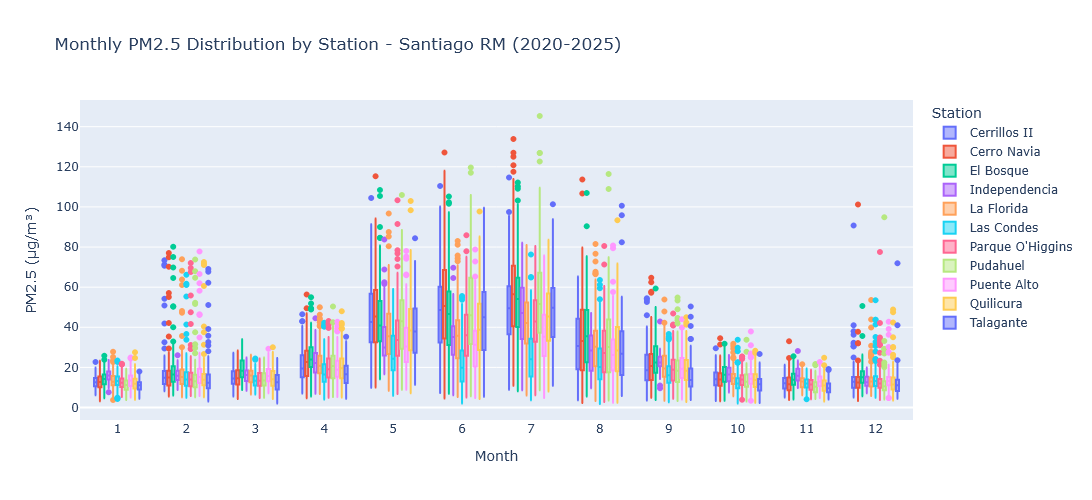

In [56]:
# Montly seasonal boxplot
fig = px.box(
    air,
    x= 'month',
    y= 'pm25_mean',
    color= 'station',
    title= 'Monthly PM2.5 Distribution by Station - Santiago RM (2020-2025)',
    labels= {
        'month': 'Month', 
        'pm25_mean': 'PM2.5 (µg/m³)',
        'station': 'Station'
    }
)

fig.update_layout(
    xaxis= dict(tickmode= 'linear', tick0=1, dtick=1),
    yaxis_title= 'PM2.5 (µg/m³)',
    legend_title= 'Station',
    height=500
)

fig.write_html('../figures/pm25_distribution_by_station.html')
fig.show()

## Monthly PM2.5 Distribution by Station

The boxplot confirms the expected seasonal pattern driven by Santiago's 
basin geography and winter temperature inversions:

- **Winter peak (May–August):** median PM2.5 across stations rises sharply,
  with several stations exceeding 50 µg/m³ (Chile's legal daily standard)
  regularly during this period.
- **Summer trough (October–February):** values drop significantly, with 
  most stations clustering below 20 µg/m³.
- **Outliers:** July and August show extreme daily readings above 120 µg/m³
  at some stations, likely corresponding to cold snaps with strong inversions.
- **Station variation:** some stations (Cerro Navia, El Bosque, Pudahuel) 
  show consistently higher values than Las Condes, which is consistent with 
  the socioeconomic geography of Santiago.

In [57]:
# Station comparison: mean, median and std of PM2.5
station_stats = air.groupby('station')['pm25_mean'].agg(
    mean= 'mean',
    median= 'median',
    std= 'std'
).reset_index().sort_values('mean', ascending=False)

# Add severity category based on mean PM2.5
def get_severity(mean):
    if mean >= 25:
        return 'High'
    elif mean >=20:
        return 'Moderate'
    else:
        return 'Low'

station_stats['severity'] = station_stats['mean'].apply(get_severity)

print(station_stats)        

             station       mean     median        std  severity
2          El Bosque  27.483782  20.354167  18.507508      High
1        Cerro Navia  26.799354  17.958333  21.291693      High
0       Cerrillos II  25.850838  17.666667  18.670405      High
3      Independencia  24.699852  20.000000  14.082431  Moderate
7           Pudahuel  24.654556  16.166667  20.314421  Moderate
4         La Florida  23.256909  17.708333  14.711082  Moderate
9          Quilicura  22.951997  16.583333  16.326585  Moderate
10         Talagante  22.181579  14.416667  18.076334  Moderate
6   Parque O'Higgins  22.030302  16.181818  14.866634  Moderate
8        Puente Alto  21.370124  17.347826  12.247864  Moderate
5         Las Condes  17.788722  14.833333  10.013033       Low


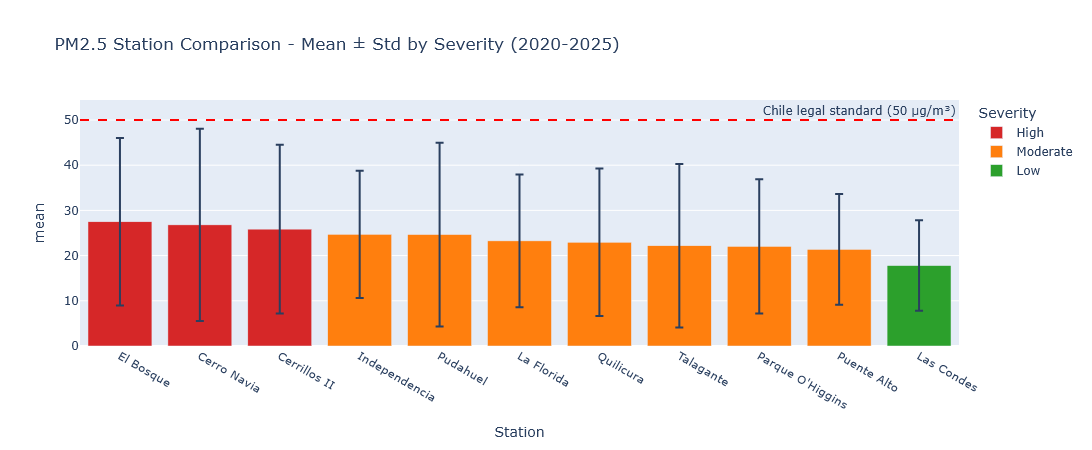

In [58]:
# Severity Graph
fig = px.bar(
    station_stats,
    x= 'station',
    y= 'mean',
    error_y= 'std',
    color= 'severity',
    color_discrete_map= {
        'High': '#d62728',
        'Moderate': '#ff7f0e',
        'Low': '#2ca02c'
    },
    title= 'PM2.5 Station Comparison - Mean ± Std by Severity (2020-2025)',
    labels={
        'station': 'Station',
        'pm25_mean': 'Mean PM2.5 (µg/m³)',
        'severity': 'Severity'
    },
    category_orders= {'severity': ['High', 'Moderate', 'Low']}
)

fig.add_hline(
    y=50,
    line_dash= 'dash',
    line_color= 'red',
    annotation_text= 'Chile legal standard (50 µg/m³)',
    annotation_position= 'top right'
)

fig.update_layout(height= 450)
fig.write_html('../figures/station_comparison_severity.html')
fig.show()

## PM2.5 Station Comparison — Mean ± Std by Severity (2020–2025)

Stations are classified by severity based on their mean PM2.5:
High (≥25 µg/m³), Moderate (20–25 µg/m³), and Low (<20 µg/m³).
Error bars show one standard deviation, revealing variability across days.

Key findings:
- **High severity:** El Bosque, Cerro Navia, and Cerrillos II are all 
  peripheral comunas with higher poverty rates, consistent with patterns 
  of environmental inequality in Santiago. Their error bars reach the 
  50 µg/m³ legal threshold, meaning these stations regularly record 
  dangerous daily readings during winter.
- **Low severity:** Las Condes is the only station in the Low category, 
  recording the cleanest air on average, consistent with its status as 
  the wealthiest comuna in the dataset.
- The gap between the most and least polluted stations is approximately 
  9 µg/m³, which is meaningful at chronic exposure levels.


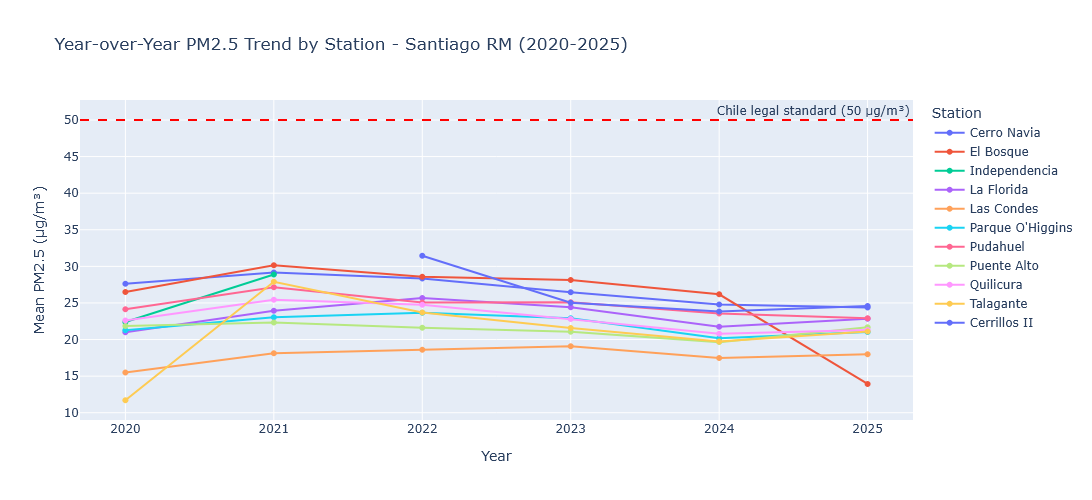

In [59]:
# Year over year trend line per station
yearly_means = air.groupby(['year', 'station'])['pm25_mean'].mean().reset_index()

fig = px.line(
    yearly_means,
    x= 'year',
    y= 'pm25_mean',
    color= 'station',
    markers= True,
    title= 'Year-over-Year PM2.5 Trend by Station - Santiago RM (2020-2025)',
    labels={
        'year': 'Year',
        'pm25_mean': 'Mean PM2.5 (µg/m³)',
        'station': 'Station'
    }
)

fig.add_hline(
    y= 50,
    line_dash= 'dash',
    line_color= 'red',
    annotation_text= 'Chile legal standard (50 µg/m³)',
    annotation_position= 'top right'
)

fig.update_layout(height=500)
fig.write_html('../figures/yearly_trend_by_station.html')
fig.show()

## Year-over-Year PM2.5 Trend by Station (2020–2025)

- **2020 dip:** Most stations record their lowest values in 2020, consistent 
  with reduced traffic and industrial activity during COVID-19 lockdowns in 
  Santiago. This provides a natural experiment showing the impact of human 
  activity on air quality.
- **2021 rebound:** Values rise across nearly all stations as activity 
  returned to normal, confirming that the 2020 dip was driven by behavioural 
  change rather than a meteorological anomaly.
- **General downward trend (2021–2025):** Most stations show a gradual 
  decline after the 2021 peak, which may reflect improvements in vehicle 
  emissions standards, increased electrification of public transport, or 
  stricter air quality regulations in the RM.
- **Cerrillos II 2022:** This station only has data from April 2022 onwards, 
  meaning its 2022 annual mean is calculated from 8 months of data that 
  include the winter peak. This inflates the 2022 value relative to 
  subsequent full years and should not be interpreted as a true anomaly.
- **Talagante 2020:** This station has no validated data for most of 2020, 
  with monitoring starting from mid-2021. Its 2020 value should be excluded 
  from any trend interpretation.
- **2025 caveat:** El Bosque only have data through early March 2025, covering
  summer months with naturally low PM2.5. Its 2025 values are not comparable
  to full-year figures for other stations.


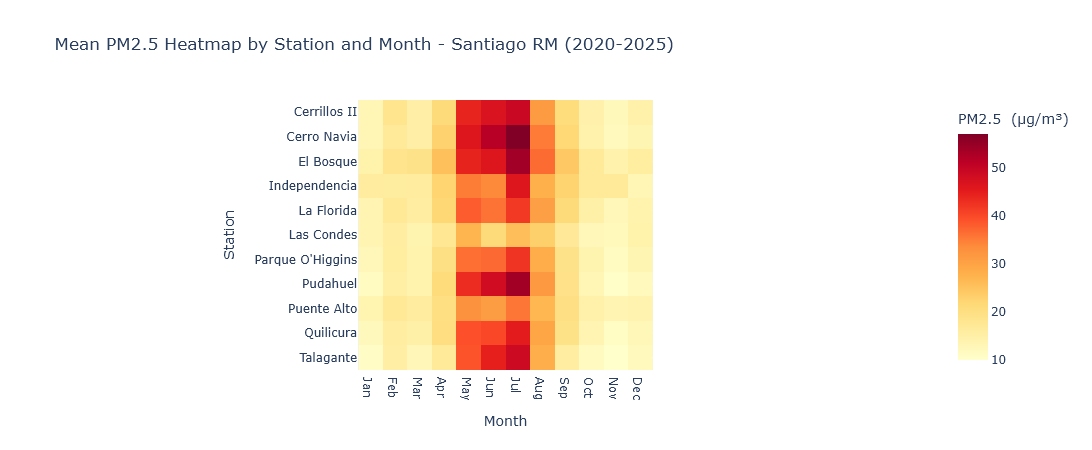

In [60]:
# Seasonal heatmap by station
heatmap_data = air.groupby(['station', 'month'])['pm25_mean'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='station', columns= 'month', values='pm25_mean')

# Rename months to abbreviate names
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 
               9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
heatmap_pivot.columns = [month_names[m] for m in heatmap_pivot.columns]

fig = px.imshow(
    heatmap_pivot,
    color_continuous_scale= 'YlOrRd',
    title= 'Mean PM2.5 Heatmap by Station and Month - Santiago RM (2020-2025)',
    labels= {'x': 'Month', 'y': 'Station', 'color': 'PM2.5  (µg/m³)'}
)

fig.update_layout(height= 450)
fig.write_html('../figures/seasonal_heatmap.html')
fig.show()

## Seasonal PM2.5 Heatmap by Station and Month

This heatmap summarises the full seasonal and spatial pattern of PM2.5 
across all stations in a single view.

Key findings:
- **Winter peak (May–August):** All stations show a clear concentration of 
  high PM2.5 during winter months, driven by Santiago's basin geography and 
  temperature inversions that trap pollution near the ground.
- **June–July hotspot:** The darkest cells correspond to Cerro Navia, 
  El Bosque, and Pudahuel in June and July, consistently exceeding 
  50 µg/m³ on average during these months.
- **Las Condes:** Visibly lighter than all other stations across every month, 
  confirming its status as the cleanest station in the dataset and 
  reflecting its location on the eastern edge of the city with better 
  ventilation from the Andes.
- **Summer baseline (December–March):** All stations converge toward 
  similar low values, suggesting that the socioeconomic gap in air quality 
  is primarily a winter phenomenon driven by heating and inversion layers 
  rather than a year-round structural difference.


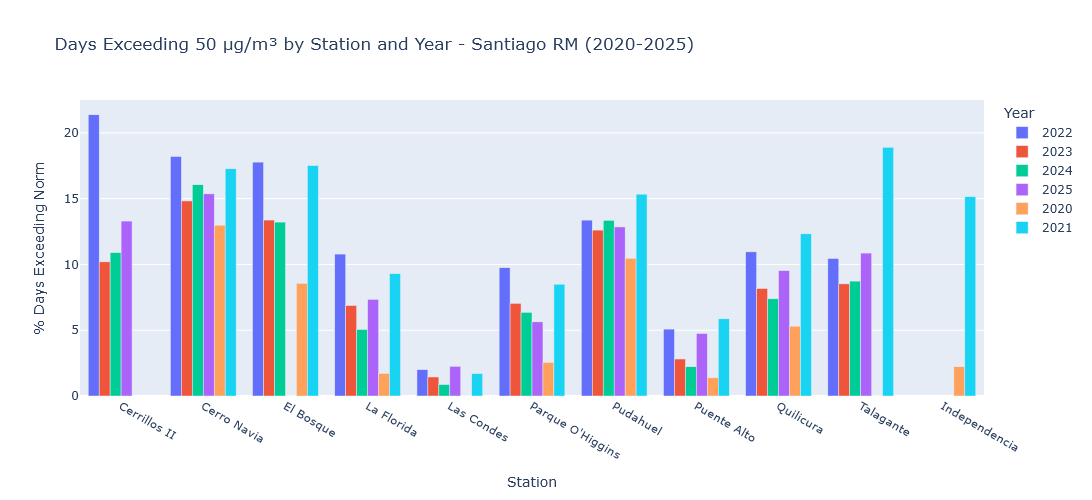

In [61]:
# Exceedance rate by station and year
exceedance = air.groupby(['station', 'year'])['exceeds_norm'].mean().reset_index()
exceedance['exceedance_pct'] = exceedance['exceeds_norm'] * 100
exceedance['year'] = exceedance['year'].astype(str)

fig = px.bar(
    exceedance,
    x= 'station',
    y= 'exceedance_pct',
    color= 'year',
    barmode= 'group',
    title= 'Days Exceeding 50 µg/m³ by Station and Year - Santiago RM (2020-2025)',
    labels= {
        'station': 'Station',
        'exceedance_pct': '% Days Exceeding Norm',
        'year': 'Year'
    }
)

fig.update_layout(
    height= 500,
    barmode= 'group'
)

fig.write_html('../figures/exceedance_rate.html')
fig.show()

## Days Exceeding 50 µg/m³ by Station and Year (2020–2025)

This chart shows the percentage of days per year where daily mean PM2.5 
exceeded Chile's legal standard of 50 µg/m³, broken down by station and year.

Key findings:
- **Cerrillos II 2022:** The highest bar in the chart reflects the partial 
  year coverage starting in April 2022, which captures only winter months 
  with naturally higher PM2.5. This inflates the exceedance rate and is 
  not comparable to full-year figures.
- **Talagante 2021:** Similarly inflated due to monitoring starting 
  mid-2021, capturing only the second half of the year including winter.
- **Las Condes:** Consistently the lowest exceedance rate across all years, 
  rarely exceeding 2–3% of days annually.
- **Cerro Navia and El Bosque:** Consistently among the highest exceedance 
  rates in years with complete data, reaching 13–18% of days per year, 
  meaning roughly one in every six to eight days exceeds the legal standard.
- **General downward trend:** Most stations show lower exceedance rates in 
  2023 and 2024 compared to earlier years, consistent with the year-over-year 
  trend observed previously.


# Analysis Summary

This notebook analysed PM2.5 air quality patterns across 11 monitoring 
stations in Santiago's Región Metropolitana between 2020 and 2025.

## Key findings

- **Seasonal pattern:** PM2.5 peaks sharply during winter (May–August) 
  across all stations, driven by temperature inversions that trap pollution 
  in Santiago's basin geography. Summer months show consistently low values 
  across all stations.

- **Spatial inequality:** A clear socioeconomic gradient exists in air 
  quality. El Bosque, Cerro Navia, and Cerrillos II (peripheral, higher-poverty 
  comunas) record the highest mean PM2.5 (26–27 µg/m³), while Las Condes
  (wealthiest comuna) records the lowest (~18 µg/m³).

- **COVID-19 effect (2020):** Most stations recorded their lowest annual 
  means in 2020, consistent with reduced traffic and industrial activity 
  during lockdowns, providing a natural experiment on the impact of human 
  activity on air quality.

- **Improving trend:** A general downward trend in PM2.5 is visible across 
  most stations from 2021 onwards, which may reflect improvements in 
  vehicle emissions standards and public transport electrification.

- **Exceedance rates:** In years with complete data, high-severity stations 
  exceed the 50 µg/m³ legal standard on roughly 13–18% of days annually, 
  meaning one in every six to eight days poses a health risk.

## Data caveats
- Cerrillos II has data from April 2022 only.
- Talagante has data from mid-2021 only.
- El Bosque and Cerrillos II have data only through early March 2025.
- These gaps affect year-level comparisons for the affected stations.

